# MATPMD4 Assignment 1 (Stochastic Processes)

**Student ID:** 3539054  
**Module:** MATPMD4  
**Date:** March 2026

---
### Instructions

I confirm that I have read and understood the instructions on the cover page.

In [1]:
# Required Imports
# !pip install numpy matplotlib scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set precision for cleaner output
np.set_printoptions(precision=4, suppress=True)

## Question 2

### 2(a) Calculating $x$

**Reasoning:**
The matrix $P$ is a **stochastic matrix**. A fundamental property of stochastic matrices is that the sum of probabilities in any given row must equal exactly $1$. Mathematically, this is because the process must transition to *some* state (including potentially staying in the same state) in the next time step.

$$\sum_{j} P_{ij} = 1 \quad \forall i$$

For the third row (State C), we have:
$$0.16 + 0.16 + 0.22 + x + 0.26 = 1$$
$$0.80 + x = 1 \implies x = 0.2$$

In [2]:
# Row C is [0.16, 0.16, 0.22, x, 0.26]
# Stochastic matrix property: sum of probabilities in a row must equal 1.
x = 1.0 - (0.16 + 0.16 + 0.22 + 0.26)
x = round(x, 2)  # Round to avoid floating point errors

print(f"\nCalculated x: {x}")

# Define the Transition Matrix P
# Rows: A, B, C, D, E
P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.00, 1.00, 0.00, 0.00, 0.00],
    [0.16, 0.16, 0.22,    x, 0.26],
    [0.00, 0.00, 0.00, 1.00, 0.00],
    [0.21, 0.27, 0.18, 0.24, 0.10]
])

print("\nTransition Matrix P:\n", P)


Calculated x: 0.2

Transition Matrix P:
 [[0.21 0.07 0.15 0.11 0.46]
 [0.   1.   0.   0.   0.  ]
 [0.16 0.16 0.22 0.2  0.26]
 [0.   0.   0.   1.   0.  ]
 [0.21 0.27 0.18 0.24 0.1 ]]


### State Transition Diagram

![Figure 1: State transition diagram.](https://raw.githubusercontent.com/Daniel-Ope06/MATPMD4-Assignment-1-Stochastic-Processes/main/assets/state_diagram.png)

*Figure 1: State transition diagram showing transition probabilities $P_{ij}$ for states A-E.*

### 2(b) Distribution after 3 Generations

**Observation:**  
As the number of generations increases, the probability values in the state vector **pi** change significantly:

- The probabilities for states **A** and **C** are consistently **decreasing**.
- The probability for state **E increases initially** (due to inflow from A and C) before eventually **decreasing**.
- The probabilities for states **B** and **D** are consistently **increasing**.

**Explanation:**  
This behavior is expected because **B** and **D** are **absorbing states**.

- Looking at the transition matrix $P$ (and the diagram), states **B** and **D** have a **self-loop probability of 1.0** ($P_{BB}=1, P_{DD}=1$).
- This means once the process enters state B or D, it cannot leave.
- States **A**, **C**, and **E** are **transient states**, meaning the process will eventually leave them and get trapped in B or D.
- Therefore, as $n \to \infty$, the total probability of being in **A, C, or E drops to 0**, while the total probability **accumulates** entirely into states **B** and **D**.


In [3]:
# Initial distribution: A(13%), B(24%), C(32%), D(28%), E(3%)
pi_0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])
print(f"Gen 0 Distribution: {pi_0}")

# Generation 1
# Using @ for matrix multiplication
pi_1 = pi_0 @ P
print(f"\nGen 1 Distribution: {pi_1}")

# Generation 2
pi_2 = pi_1 @ P
print(f"\nGen 2 Distribution: {pi_2}")

# Generation 3
pi_3 = pi_2 @ P
print(f"\nGen 3 Distribution: {pi_3}")

Gen 0 Distribution: [0.13 0.24 0.32 0.28 0.03]

Gen 1 Distribution: [0.0848 0.3084 0.0953 0.3655 0.146 ]

Gen 2 Distribution: [0.0637 0.369  0.06   0.4289 0.0784]

Gen 3 Distribution: [0.0394 0.4042 0.0369 0.4667 0.0527]


### 2(c) Canonical Form

We rewrite $P$ in canonical form by reordering the states so that absorbing states appear first, followed by transient states.

- **Absorbing States:** B, D
- **Transient States:** A, C, E

The canonical form is partitioned as:
$$P = \begin{pmatrix} I & 0 \\ R & Q \end{pmatrix}$$
Where $Q$ represents transitions between transient states, and $R$ represents transitions from transient to absorbing states.

In [4]:
# Current State Order: A(0), B(1), C(2), D(3), E(4)
# Absorbing States: B(1), D(3)
# Transient States: A(0), C(2), E(4)

# The new order to group Absorbing first, then Transient.
# New Order: B, D, A, C, E
canonical_order = [1, 3, 0, 2, 4]

# Move Row B to top & Row D to second to top
P_rows_sorted = P[canonical_order, :]

# Move Col B to left, Col D to second to left
P_canonical = P_rows_sorted[:, canonical_order]

print("Canonical Matrix P_canonical:\n", P_canonical)

# Structure of Canonical Form:
# | I  0 |  (Absorbing rows)
# | R  Q |  (Transient rows)

# 2 absorbing states and 3 transient states.
num_absorbing = 2
num_transient = 3

# Q: Transient to Transient (Bottom-Right block)
# Take rows from index 2 to end, and columns from index 2 to end
Q = P_canonical[num_absorbing:, num_absorbing:]

print("\nMatrix Q (Transient -> Transient):\n", Q)

# R: Transient to Absorbing (Bottom-Left block)
# Take rows from index 2 to end, and columns from index 0 to 2
R = P_canonical[num_absorbing:, :num_absorbing]

print("\nMatrix R (Transient -> Absorbing):\n", R)

Canonical Matrix P_canonical:
 [[1.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.  ]
 [0.07 0.11 0.21 0.15 0.46]
 [0.16 0.2  0.16 0.22 0.26]
 [0.27 0.24 0.21 0.18 0.1 ]]

Matrix Q (Transient -> Transient):
 [[0.21 0.15 0.46]
 [0.16 0.22 0.26]
 [0.21 0.18 0.1 ]]

Matrix R (Transient -> Absorbing):
 [[0.07 0.11]
 [0.16 0.2 ]
 [0.27 0.24]]


### 2(d) Fundamental Matrix $N$

The fundamental matrix $N$ gives the expected number of times the process is in transient state $j$, given it started in transient state $i$.

**Formula:**
$$N = (I - Q)^{-1}$$

**Components:**
- $I$: Identity matrix of size equivalent to the number of transient states (3x3).
- $Q$: The matrix describing probabilities of moving between transient states (*A, C, E*).

In [5]:
I = np.eye(3)
N = np.linalg.inv(I - Q)

print("Fundamental Matrix N:\n", N)

Fundamental Matrix N:
 [[1.6412 0.5456 0.9964]
 [0.4975 1.539  0.6989]
 [0.4824 0.4351 1.4834]]


### 2(e) Mean Time to Absorption

This calculates the expected number of steps before the process hits *any* absorbing state, given it starts in a specific transient state.

**Formula:**
$$M = N \mathbf{1}$$

**Components:**
- $N$: The fundamental matrix calculated in 2(d).
- $\mathbf{1}$: A column vector of ones.
- Summing the rows of $N$ (which is what multiplying by $\mathbf{1}$ does) adds up the expected visits to *all* transient states, giving the total lifetime of the process.

In [6]:
# Formula: M = N @ 1 (column vector of ones)
ones = np.ones((3, 1))
M = N @ ones

print("Mean steps to absorption (from A, C, E):")
print(M)

Mean steps to absorption (from A, C, E):
[[3.1832]
 [2.7353]
 [2.4009]]


### 2(f) Absorption Probabilities

This calculates the probability that the process will be absorbed into a specific absorbing state (B or D).

**Formula:**
$$B = N R$$

**Components:**
* $N$: The fundamental matrix representing time spent in transient states.
* $R$: The matrix of probabilities of moving from a transient state directly to an absorbing state.
* Multiplying $N$ by $R$ aggregates the probabilities of all paths leading to a specific absorbing state.

In [7]:
# Formula: B = N @ R
B = N @ R

print("Absorption Probabilities (Rows: A, C, E | Cols: B, D):")
print(B)

Absorption Probabilities (Rows: A, C, E | Cols: B, D):
[[0.4712 0.5288]
 [0.4698 0.5302]
 [0.5039 0.4961]]


## Question 3

### 3(a) Parameters and Expected Behaviour

**Student Number:** 3539054

- $\alpha = 353 / 100 = 3.53$
- $\beta = 054 / 100 = 0.54$

**Random Walk Equation:**

$$
dS = a(x,t)dt + b(x,t)dW
\\
a(x,t) = (\frac{1}{\alpha})\sin{(x)}\cos{(t)} = 0.283\sin{(x)}\cos{(t)}
\\
b(x,t) = (\frac{1}{\beta}) = 1.852
\\
dS = 0.283\sin{(x)}\cos{(t)}dt + 1.852dW
$$

**Expected Trajectory:**

The trajectory should be a noisy path that roughly oscillates around a central band over time, with no long-term upward or downward trend.

**Justification:**

Deduce the behaviour by analysing the terms $a(x,t)$ and $b(x,t)$ separately:

1. **The Oscillatory Drift $a(x,t)$:**

    - The $\cos(t)$ component alternates smoothly between 1 and -1. This means the deterministic push of the walk periodically reverses direction.
    - The $\sin(x)$ term means the strength of that push depends on where the walker currently is. If $x$ is at a multiple of $\pi$, the sine is 0, meaning the drift disappears entirely.
    - Because the drift inherently cancels itself out over time, the walk cannot sustain a long-term upward or downward trend. It is forced into a periodic oscillation.

2. **The Dominant Noise $b(x,t)$:**

    - The magnitude of this noise ($1.852$) is significantly larger than the maximum possible magnitude of the drift ($0.283$).
    - While the underlying drift attempts to create a smooth, bounded oscillation, the overpowering noise will make the actual trajectory appear highly erratic and heavily randomised step-to-step.



### 3(b) Identifying and Fixing the Bug

**The Bug:**  
The error lies in how $dW$ is simulated. The code implements it as `np.random.normal(0,1)`. 

- In the Generalised Wiener Process, $dW$ must be drawn from a normal distribution with a mean of 0 and a **variance of $dt$** (meaning a standard deviation of $\sqrt{dt}$).
- By using `np.random.normal(0,1)`, the code generates noise with a constant variance of 1, regardless of the time step size.
- This incorrectly causes the diffusion term to scale independently of time, overpowering the simulation.

**The Fix:**  
To fix this, scale the standard normal random variable by $\sqrt{dt}$. 

```python
x = 0
for i in range(N):
    t = i * dt
    x = x + (1/alpha)*np.sin(x)*np.cos(t)*dt + (1/beta)*np.random.normal(0, 1)*np.sqrt(dt)
```

### 3(c) Explanation of Differing Realisations

As shown in the plot below, the three realisations diverge from one another. 

**Why they differ:**  
Even though all three walks start at $x=0$ and follow the exact same governing stochastic differential equation, they differ because of the stochastic diffusion term, $b(x,t)dW$. 

- At every single time step $dt$, the code draws a completely independent, random value from a normal distribution to simulate $dW$.
- Over the course of 2500 steps, these thousands of independent random noise accumulate.
- Because the noise term is the dominant force in this specific equation (as explained in 3a), the compounding effect of these random draws causes the paths to deviate entirely from one another, creating unique trajectories every time the simulation is run.

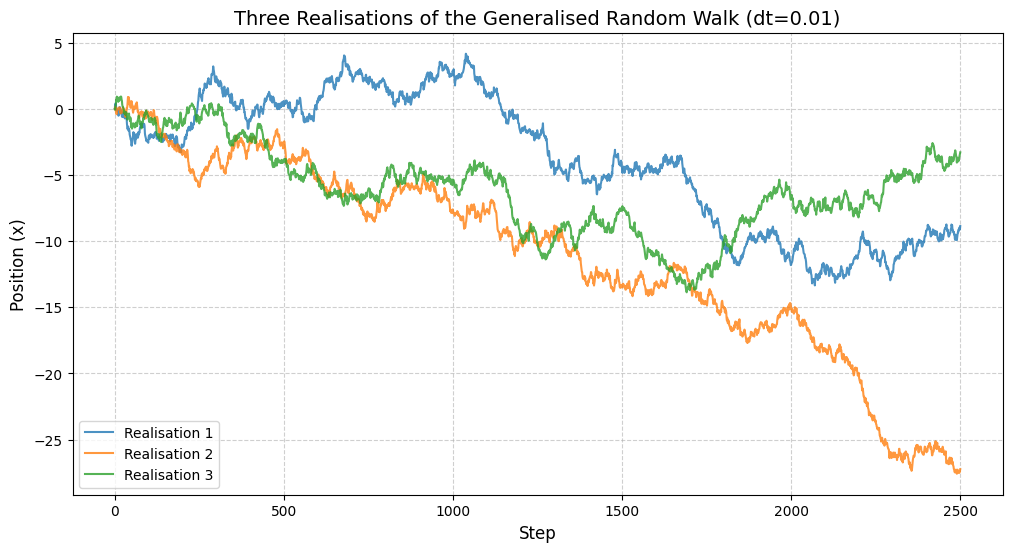

In [8]:
np.random.seed(3)

# Parameters
alpha = 3.53
beta = 0.54
dt = 0.01
N = 2500

plt.figure(figsize=(12, 6))

# Generate 3 different realisations
for walk in range(3):
    x = 0
    path = [x]
    
    for i in range(N):
        t = i * dt
        dx = (1/alpha) * np.sin(x) * np.cos(t) * dt + (1/beta) * np.random.normal(0, 1) * np.sqrt(dt)
        x = x + dx
        path.append(x)
        
    plt.plot(path, alpha=0.8, linewidth=1.5, label=f'Realisation {walk + 1}')

plt.title('Three Realisations of the Generalised Random Walk (dt=0.01)', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Position (x)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3(d) Mean Position Analysis

**Results:**  
The code below displays the mean final position for $dt = 0.05, 0.1, 0.2, 0.4$. Across all tested values of $dt$, the mean position remains close to 0.

**Explanation:**  
These results are expected due to the mathematical structure of the stochastic differential equation $dS = a(x,t)dt + b(x,t)dW$.

1. **Symmetric Noise:** The random diffusion term is driven by a standard normal distribution centred around 0. Over 1000 independent walks, the positive and negative random noise average out to zero.

2. **Symmetric Drift:** The deterministic drift term includes $\sin(x)$. Since the walk starts at $x=0$, the initial drift is exactly 0. Furthermore, the sine function is an odd function ($\sin(-x) = -\sin(x)$). This means if the noise pushes the walk into positive territory, the drift behaves one way, but if it pushes it identically into negative territory, the drift behaves in the exact opposite way.

**Conclusion:**  
Because both the noise and the spatial drift behave symmetrically around the starting point of $x=0$, there is no mathematical bias pushing the aggregate population of walks predominantly upward or downward. Therefore, the expected mean position of many independent walks will always be approximately 0, regardless of the time step size $dt$.

In [9]:
np.random.seed(0)

num_walks = 1000
dt_values = [0.05, 0.1, 0.2, 0.4]

print(f"Mean final position after {N} steps (averaged over {num_walks} walks):")
print("-" * 64)

for dt in dt_values:
    # Initialize a vector 'x' to track the positions of all 1000 walks.
    # x_0 = 0 for all paths.
    x = np.zeros(num_walks)

    for i in range(N):
        t = i * dt

        # Drift: a(x,t)*dt
        # Passing the vector 'x' into np.sin() calculates the spatial drift
        # for all 1000 walks simultaneously (element-wise).
        drift = (1/alpha) * np.sin(x) * np.cos(t) * dt

        # Noise: b(x,t)*dW
        # size=num_walks forces NumPy to draw 1000 independent samples.
        # Every single walk receives its own independent random noise.
        noise = (1/beta) * np.random.normal(0, 1, size=num_walks) * np.sqrt(dt)

        # This vector addition updates the positions of all 1000 walks at once,
        # mathematically identical to running 1000 separate loops, but faster.
        x = x + drift + noise

    mean_position = np.mean(x)
    print(f"dt = {dt} | Mean Final Position = {mean_position:.4f}")


Mean final position after 2500 steps (averaged over 1000 walks):
----------------------------------------------------------------
dt = 0.05 | Mean Final Position = 0.3550
dt = 0.1 | Mean Final Position = -0.0650
dt = 0.2 | Mean Final Position = 1.6930
dt = 0.4 | Mean Final Position = 0.7062


### 3(e) Histogram and Normality Test

**Visual Assessment:**  
The histogram of the final positions for 5000 walks visually resembles a normal distribution (a bell-shaped curve) centred around 0. This central clustering aligns with the findings in 3(d).

**Statistical Testing:**  
Used D'Agostino's K-squared test (`scipy.stats.normaltest`) to formally test if the data is normally distributed.

- **Null Hypothesis:** It is a normal distribution
- **Test Statistic:** 0.0979
- **p-value:** 0.9522

**Conclusion:**  
Using a standard significance level of $\alpha_{sig} = 0.05$, the p-value is larger than the threshold ($p > 0.05$). Therefore, we fail to reject the null hypothesis. This supports the visual assessment that it is a normal distribution.

In [10]:
np.random.seed(3)

num_walks = 5000

# Initialize a vector 'x' to track the positions of all walks.
x = np.zeros(num_walks)

for i in range(N):
    t = i * dt
    drift = (1/alpha) * np.sin(x) * np.cos(t) * dt
    noise = (1/beta) * np.random.normal(0, 1, size=num_walks) * np.sqrt(dt)
    x = x + drift + noise

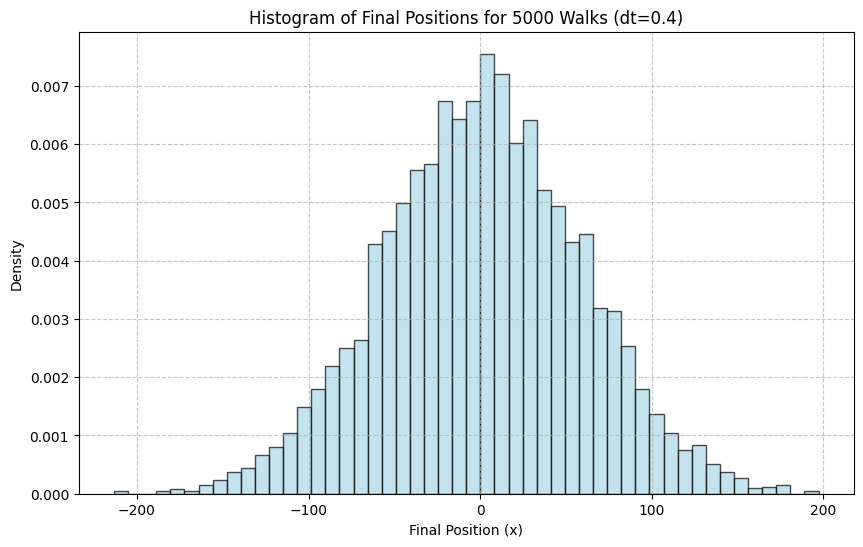

In [11]:
# Plotting the histogram
plt.figure(figsize=(10, 6))
# Using density=True to normalize the histogram,
# making it easier to compare to a standard curve
plt.hist(
    x, bins=50, density=True, alpha=0.7,
    color='lightblue', edgecolor='black'
)
plt.title(f'Histogram of Final Positions for {num_walks} Walks (dt={dt})')
plt.xlabel('Final Position (x)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [12]:
# Run D'Agostino's K-squared test for normality
stat, p_value = stats.normaltest(x)
print(f"Normality Test Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

Normality Test Statistic: 0.0979
p-value: 0.9522


### 3(f) Probability of $|x| \leq 2$

**Empirical Calculation:**  
Using 5000 realisations generated in 3(e), the estimated probability is:

$$P(|x| \le 2) \approx 0.0282$$

**Dependency Analysis:**  
Yes, this probability depends on both the time step size ($dt$) and the number of steps ($N$). 

1. **The Mathematical Relationship:** In a stochastic process like this one, the variance of the distribution grows linearly with the total elapsed time, $T$. The total time is defined as $T = N \times dt$.

2. **Impact of $dt$ and $N$:** Because the variance is proportional to $(N \times dt)$, increasing either the number of steps or the size of the time step will increase the total variance of the final positions.

**Conclusion:**  
As variance increases, the bell curve of final positions widens and flattens out. A wider distribution means a smaller proportion of the total probability mass remains clustered near the origin. Therefore, increasing either $dt$ or $N$ will decrease the probability that a walk ends up within the bounds of $[-2, 2]$.

In [13]:
# Using the array 'x' (final positions of 5000 walks) generated in 3(e)

# Count how many walks ended up between -2 and 2
walks_in_range = np.sum((x >= -2) & (x <= 2))

# Calculate the empirical probability
probability = walks_in_range / len(x)

print(f"Number of walks ending in range [-2, 2]: {walks_in_range} out of {len(x)}")
print(f"Empirical Probability P(|x| <= 2): {probability:.4f}")

Number of walks ending in range [-2, 2]: 141 out of 5000
Empirical Probability P(|x| <= 2): 0.0282


## Question 4

### 4(a) Theoretical Concepts of Metropolis-Hastings

**i. Probabilistic Acceptance of "Worse" Moves**  
If an algorithm only ever accepts strictly "better" moves, it will simply climb the nearest hill and get permanently trapped on a local maximum. The Metropolis-Hastings algorithm solves this by always accepting better proposals, but also occasionally accepting worse proposals with a frequency proportional to *how much* worse they are. By allowing the chain to temporarily walk through low-density "valleys," the algorithm can escape suboptimal peaks and continue exploring the space to find the true global maximum.

**ii. Impact of Proposal Standard Deviation ($\sigma$)**  
The algorithm uses a proposal distribution (e.g. a Gaussian kernel) to decide where to step next, and $\sigma$ controls the size of that step. If $\sigma$ is too small, the algorithm takes tiny, highly correlated steps, exploring the space far too slowly; while, if $\sigma$ is too large, it takes massive, erratic jumps that mostly land in terrible, low-density regions. A well-tuned $\sigma$ perfectly balances steady exploration with efficient peak-climbing.

**iii. Suitability for High-Dimensional Optimisation**  
Traditional approaches like *grid search* suffer from the *curse of dimensionality*. If you evaluate a function across a grid, the computational cost grows exponentially with each added dimension, wasting billions of calculations on empty, low-value space. Metropolis-Hastings entirely avoids this exhaustive search by using a Markov chain which acts as a directed random walk that naturally gravitates toward the *typical set* (the narrow regions where the actual probability mass lies).

### 4(b) Identifying and Fixing the Bug

**The Bug:**  
Accepting a move when `f_proposal > f_current` is perfectly correct. However, the error lies in what the code does next, by lacking an `else` statement, it implicitly rejects **all** moves that are worse. 

**Buggy Snippet:**  
```python
# Accept if better, reject if worse
if f_proposal > f_current:
    x_current = x_proposal
    f_current = f_proposal
```

**Why this fails for optimisation:**  
If an algorithm can only move strictly upwards, it will immediately get trapped at the peak of the very first hill (local maximum) it encounters. 
  
A true Metropolis-Hastings algorithm must occasionally accept worse proposals. It does this by evaluating the ratio of the new state to the old state. If the new state is worse, it is not automatically rejected but accepted with a probability proportional to that ratio. This probabilistic acceptance allows the Markov chain to walk down into low-density "valleys," effectively escaping local traps so it can continue exploring to find the true global maximum.

**Corrected Snippet:**  
```python
# Accept if better
if f_proposal > f_current:
    x_current = x_proposal
    f_current = f_proposal
    
# If worse, accept with a probability proportional to how much worse it is
else:
    acceptance_probability = f_proposal / f_current
    if np.random.uniform(0, 1) < acceptance_probability:
        x_current = x_proposal
        f_current = f_proposal
```

### 4(c) Analysis of Metropolis-Hastings Runs

**i. 5 Runs of Metropolis-Hastings Algorithm**  

In [14]:
def f(w,x,y,z):
    himmel1 = -((w**2 + x - 11)**2 + (w + x**2 - 7)**2) / 100
    himmel2 = -((y**2 + z - 11)**2 + (y + z**2 - 7)**2) / 100
    peak1 = 4.0 * np.exp(-0.2 * ((w-2.5)**2 + (x-1.8)**2 + (y+1.2)**2 + (z-0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w+1.8)**2 + (x-2.2)**2 + (y-2.5)**2 + (z+1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w-0.5)**2 + (x+2.8)**2 + (y-1.8)**2 + (z+2.3)**2))
    peak4 = 3.3 * np.exp(-0.25 * ((w+2.2)**2 + (x+0.8)**2 + (y+2.5)**2 + (z-2.1)**2))
    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)
    
    return himmel1 + himmel2 + peak1 + peak2 + peak3 + peak4 + interaction

In [15]:
def metropolis_hastings(f, x_init, sigma, n_steps):
    x_current = x_init
    f_current = f(*x_current)
    f_history = [f_current]
    x_history = [x_current.copy()]

    for i in range(n_steps):
        x_proposal = x_current + np.random.normal(0, sigma, size=4)
        f_proposal = f(*x_proposal)

        # Accept if better
        if f_proposal > f_current:
            x_current = x_proposal
            f_current = f_proposal

        # If worse, accept with a probability
        # proportional to how much worse it is
        else:
            acceptance_probability = f_proposal / f_current
            if np.random.uniform(0, 1) < acceptance_probability:
                x_current = x_proposal
                f_current = f_proposal

        f_history.append(f_current)
        x_history.append(x_current.copy())

    return f_history, x_history

In [16]:
def analyze_run(f_history, x_history):
    # Find Best Value and Position
    best_index = np.argmax(f_history)
    best_f = f_history[best_index]
    best_x = x_history[best_index]

    # Calculate Acceptance Ratio
    # If history[i] != history[i-1], the move was accepted.
    f_history_arr = np.array(f_history)
    accepted_moves = np.sum(f_history_arr[1:] != f_history_arr[:-1])
    acceptance_ratio = accepted_moves / (len(f_history) - 1)

    return best_f, best_x, acceptance_ratio

--- Run 1 ---
Max Found: 3.0972
Final Position: w=-2.93, x=2.23, y=2.85, z=-0.65
Best Position:  w=-2.13, x=2.47, y=2.97, z=-1.46
Acceptance Ratio: 59.44%

--- Run 2 ---
Max Found: 2.7499
Final Position: w=1.87, x=0.95, y=-1.83, z=1.81
Best Position:  w=2.80, x=1.95, y=-1.45, z=0.96
Acceptance Ratio: 58.60%

--- Run 3 ---
Max Found: -0.0854
Final Position: w=-3.11, x=16.00, y=-88.61, z=-11.83
Best Position:  w=3.26, x=0.48, y=3.07, z=0.82
Acceptance Ratio: 100.00%

--- Run 4 ---
Max Found: -0.7809
Final Position: w=43.20, x=22.73, y=-58.81, z=24.55
Best Position:  w=2.75, x=-1.18, y=2.25, z=-3.21
Acceptance Ratio: 100.00%

--- Run 5 ---
Max Found: -0.1885
Final Position: w=-23.59, x=-45.97, y=6.66, z=1.88
Best Position:  w=-2.94, x=-3.21, y=3.75, z=-2.06
Acceptance Ratio: 100.00%



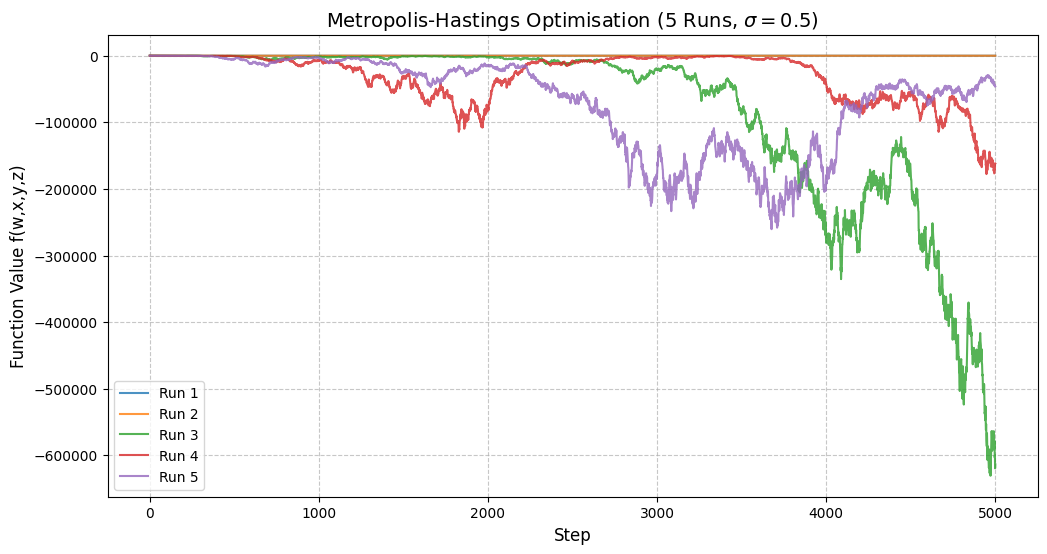

In [17]:
sigma = 0.5
n_steps = 5000
seeds = [0, 3, 4, 6, 12]

plt.figure(figsize=(12, 6))

for i, seed in enumerate(seeds):
    np.random.seed(seed)
    x_init = np.random.uniform(-3.5, 3.5, size=4)
    
    f_history, x_history = metropolis_hastings(f, x_init, sigma, n_steps)
    
    best_f, best_x, acc_ratio = analyze_run(f_history, x_history)
    
    plt.plot(f_history, alpha=0.8, linewidth=1.5, label=f'Run {i+1}')
    
    final_pos = x_history[-1]
    print(f"--- Run {i+1} ---")
    print(f"Max Found: {best_f:.4f}")
    print(f"Final Position: w={final_pos[0]:.2f}, x={final_pos[1]:.2f}, y={final_pos[2]:.2f}, z={final_pos[3]:.2f}")
    print(f"Best Position:  w={best_x[0]:.2f}, x={best_x[1]:.2f}, y={best_x[2]:.2f}, z={best_x[3]:.2f}")
    print(f"Acceptance Ratio: {acc_ratio:.2%}\n")
    
plt.title('Metropolis-Hastings Optimisation (5 Runs, $\\sigma=0.5$)', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Function Value f(w,x,y,z)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**ii. Convergence Behaviour**  
No, the runs do not all converge to the same maximum. The graph shows the chains plateauing at different function values. This indicates that the function $f()$ is highly multi-modal . The algorithm climbs the peak nearest to its random starting location, but with $\sigma=0.5$, it struggles to propose jumps large enough to cross the low-density "valleys" separating the different peaks. As a result, the chains become trapped in various local maxima.

**iii. Acceptance Ratios**  
The acceptance ratios vary significantly, ranging between 58% and 100%. They are not similar, which tells us that the local topography of the landscape changes drastically depending on which peak the chain is currently exploring.

- A **lower ratio** (e.g., 58%) suggests the chain is on a steeper, narrower peak where a step size of $\sigma=0.5$ frequently pushes the proposal off the edge into a low-value region, causing more rejections. 
- A very **high ratio** (approaching 100%) indicates the chain is wandering across a broad, relatively flat plateau where most proposed steps result in a very similar function value, making them highly likely to be accepted.

**iv. Estimated Global Maximum and Location**  
Based on the 5 independent runs, the highest estimated maximum value of $f()$ found is **3.0972**.  
The maximum is located approximately at the coordinates:
$$
(w,x,y,z) = (-2.13, 2.47, 2.97, -1.46)
\\
f(w,x,y,z) = 3.0972
$$

### 4(d) Confidence in the Global Maximum

**Confidence Level:** Low  
While the algorithm successfully found a high value ($f \approx 3.0972$), I am not confident this is the absolute true global maximum of the function.

This conclusion is justified by the following observations:

**1. The Multi-Modal Trap (Variance in Results)**  
The 5 runs converged to varying final states with vastly different acceptance ratios (ranging from 58% to 100%). This proves the 4D landscape is highly multi-modal, littered with sharp peaks and flat plateaus. While probabilistic acceptance allows the chain to sometimes escape local maxima, it can still get permanently trapped if the *valleys* separating the peaks are too wide for a proposal step of $\sigma = 0.5$ to cross.

**2. The Curse of Dimensionality vs. Sample Size**  
The Markov chains naturally gravitate toward the *typical set* of the peaks they start near. In a vast 4-dimensional space, 5 independent runs of 5,000 steps represent a microscopically small sample size. Entire regions of the domain likely remain completely unexplored.

**3. Fixed Proposal Distribution ($\sigma = 0.5$)**  
All simulations using a fixed proposal standard deviation of $\sigma = 0.5$. The algorithm's ability to explore is heavily dependent on this hyperparameter. If the true global maximum is separated from the rest of the space by a very wide, low-density valley, a step size of $0.5$ might simply be too small to ever propose a jump across it. To gain higher confidence, run many more chains using a variety of $\sigma$ values.

**How to Increase Confidence:**  
To confidently verify the global maximum, we would need to employ techniques like a Massive Multi-Start approach (running thousands of chains from a uniform grid of starting positions) or Simulated Annealing (systematically cooling the acceptance probability to force broad initial exploration before settling on a peak).